In [1]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from adjustText import adjust_text
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

font_path = '/users/PCON0022/huchen/Arial.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name

my_cmap = LinearSegmentedColormap.from_list(
    "soft_rdbl", ["#53b1dc", "#FFFFFF", "#EE6677"], N=256
)

rcParams['ps.useafm'] = True
rcParams['pdf.use14corefonts'] = True
rcParams['pdf.fonttype'] = 42 
rcParams['ps.fonttype'] = 42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)


In [2]:
sample_list = ['Young_1', 'Young_2', 'Young_3', 'Young_4', 'Young_5',
 'Old_1', 'Old_2', 'Old_3', 'Old_4', 'Old_5']


adata_dict = {}
lr_dict = {}

for sample in sample_list:
    res_dir = Path(f"/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_results/{sample}")
    os.makedirs(res_dir, exist_ok=True)
    print(res_dir)
    adata = sc.read(res_dir / "downstream.h5ad")
    lr_df = pd.read_csv(res_dir / "filtered_secreted_LR_pairs.csv")
    adata_dict[sample] = adata
    lr_dict[sample] = lr_df

/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_results/Young_1
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_results/Young_2
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_results/Young_3
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_results/Young_4
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_results/Young_5
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_results/Old_1
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_results/Old_2
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_results/Old_3
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_results/Old_4
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_results/Old_5


## Fig. 4a

In [3]:
all_data_dict = adata_dict.copy()

In [4]:
# all pathways
all_pathways = set()
for sample in sample_list:
    all_pathways.update(lr_dict[sample]["pathway"].astype(str).unique())
all_pathways = sorted(all_pathways)

for sample in sample_list:
    adata = all_data_dict[sample]
    df = lr_dict[sample].copy()

    new_cols = {}

    for pw in all_pathways:
        lrs = df.loc[df["pathway"] == pw, "complex"].tolist()

        # pathway activity: sum of adata.obs[lr]
        act_cols = [lr for lr in lrs if lr in adata.obs.columns]
        if len(act_cols) > 0:
            mat = adata.obs[act_cols].apply(pd.to_numeric, errors="coerce")
            new_cols[f"PW_{pw}"] = mat.sum(axis=1, skipna=True).astype(float).values
        else:
            new_cols[f"PW_{pw}"] = np.full(adata.n_obs, np.nan)
        
        # sig count / any_sig
        sig_cols = [f"{lr}_sig" for lr in lrs if f"{lr}_sig" in adata.obs.columns]
        if len(sig_cols) > 0:
            sig_mat = adata.obs[sig_cols].copy()
            for c in sig_cols:
                if sig_mat[c].dtype == object:
                    sig_mat[c] = sig_mat[c].astype(str).str.lower().map({"true": True, "false": False})
            sig_mat = sig_mat.fillna(False).astype(bool)
        
            new_cols[f"PW_{pw}_sig_count"] = sig_mat.sum(axis=1).astype(int).values
            new_cols[f"PW_{pw}_any_sig"] = sig_mat.any(axis=1).values
        else:
            new_cols[f"PW_{pw}_sig_count"] = np.zeros(adata.n_obs, dtype=int)
            new_cols[f"PW_{pw}_any_sig"] = np.zeros(adata.n_obs, dtype=bool)

    new_df = pd.DataFrame(new_cols, index=adata.obs_names)
    adata.obs = pd.concat([adata.obs, new_df], axis=1)

    adata.obs = adata.obs.copy()

In [34]:
use_sig_only = True
pseudocount = 1e-6
min_spots = 3

young_samples = [s for s in sample_list if s.startswith("Young")]
old_samples   = [s for s in sample_list if s.startswith("Old")]

rows = []

for pw in all_pathways:
    act_col = f"PW_{pw}"
    sig_col = f"PW_{pw}_any_sig"

    young_means = []
    old_means = []

    # ---- Young: per-sample mean (no niche) ----
    for sample in young_samples:
        adata = all_data_dict[sample]
        if act_col not in adata.obs.columns:
            continue

        mask = np.ones(adata.n_obs, dtype=bool) 

        if use_sig_only:
            if sig_col not in adata.obs.columns:
                continue
            mask = mask & adata.obs[sig_col].fillna(False).astype(bool)

        if int(mask.sum()) < min_spots:
            continue

        x = pd.to_numeric(adata.obs.loc[mask, act_col], errors="coerce")
        m = np.nanmean(x.values)
        if np.isfinite(m):
            young_means.append(float(m))

    # ---- Old: per-sample mean (no niche) ----
    for sample in old_samples:
        adata = all_data_dict[sample]
        if act_col not in adata.obs.columns:
            continue

        mask = np.ones(adata.n_obs, dtype=bool)

        if use_sig_only:
            if sig_col not in adata.obs.columns:
                continue
            mask = mask & adata.obs[sig_col].fillna(False).astype(bool)

        if int(mask.sum()) < min_spots:
            continue

        x = pd.to_numeric(adata.obs.loc[mask, act_col], errors="coerce")
        m = np.nanmean(x.values)
        if np.isfinite(m):
            old_means.append(float(m))

    mean_y = np.nanmean(young_means) if len(young_means) else np.nan
    mean_o = np.nanmean(old_means) if len(old_means) else np.nan

    log2fc = np.nan
    if np.isfinite(mean_y) and np.isfinite(mean_o):
        log2fc = float(np.log2((mean_o + pseudocount) / (mean_y + pseudocount)))

    p = np.nan
    if len(young_means) >= 2 and len(old_means) >= 2:
        p = mannwhitneyu(old_means, young_means, alternative="two-sided").pvalue

    rows.append({
        "pathway": pw,
        "n_young_samples": len(young_means),
        "n_old_samples": len(old_means),
        "mean_young": mean_y,
        "mean_old": mean_o,
        "log2FC_old_vs_young": log2fc,
        "p_mannwhitney": p,
        "use_sig_only": use_sig_only
    })

res_pw_global = pd.DataFrame(rows)

res_pw_global[["mean_young","mean_old","log2FC_old_vs_young"]] = (
    res_pw_global[["mean_young","mean_old","log2FC_old_vs_young"]].fillna(0)
)
res_pw_global["p_mannwhitney"] = res_pw_global["p_mannwhitney"].fillna(1)



# BH(FDR) correction using statsmodels
pvals = res_pw_global["p_mannwhitney"].astype(float).values
res_pw_global["fdr_bh"] = multipletests(pvals, method="fdr_bh")[1]

# sort fdr + logFC 
res_pw_global = res_pw_global.sort_values(["fdr_bh", "log2FC_old_vs_young"], ascending=[True, False])
res_pw_global.head()

,pathway,n_young_samples,n_old_samples,mean_young,mean_old,log2FC_old_vs_young,p_mannwhitney,use_sig_only,fdr_bh
10,COMPLEMENT,5,5,0.050371,0.091751,0.865125,0.007937,True,0.02328
7,CALCR,5,5,0.009079,0.015528,0.774185,0.007937,True,0.02328
9,CHEMERIN,5,5,0.038256,0.064097,0.744545,0.007937,True,0.02328
18,GALECTIN,5,5,0.022724,0.037201,0.711113,0.007937,True,0.02328
37,TGFb,5,5,0.029061,0.043977,0.597675,0.007937,True,0.02328


In [7]:
df = res_pw_global.copy()

p = np.clip(df["fdr_bh"].astype(float).values, 1e-300, 1.0)
df["neglog10p"] = -np.log10(p)

p_thresh = 0.05
fc_thresh = 0.5
sig = (df["fdr_bh"] < p_thresh) & (df["log2FC_old_vs_young"].abs() > fc_thresh)
sig_df = df.loc[sig, ["pathway", "log2FC_old_vs_young", "neglog10p", "p_mannwhitney", "fdr_bh"]].copy()
sig_df

,pathway,log2FC_old_vs_young,neglog10p,p_mannwhitney,fdr_bh
10,COMPLEMENT,0.865125,1.633009,0.007937,0.023280
7,CALCR,0.774185,1.633009,0.007937,0.023280
9,CHEMERIN,0.744545,1.633009,0.007937,0.023280
18,GALECTIN,0.711113,1.633009,0.007937,0.023280
37,TGFb,0.597675,1.633009,0.007937,0.023280
11,CSF,0.541766,1.633009,0.007937,0.023280
32,PERIOSTIN,0.822411,1.411160,0.015873,0.038801
14,EDN,0.680893,1.411160,0.015873,0.038801


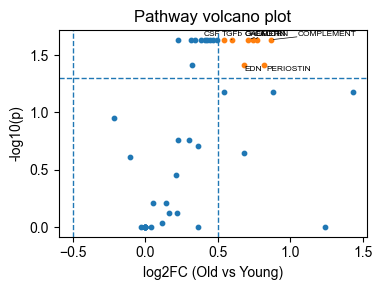

In [8]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(df.loc[~sig, "log2FC_old_vs_young"], df.loc[~sig, "neglog10p"], s=10)
ax.scatter(df.loc[sig, "log2FC_old_vs_young"], df.loc[sig, "neglog10p"], s=10)

ax.axvline(fc_thresh, linestyle="--", linewidth=1)
ax.axvline(-fc_thresh, linestyle="--", linewidth=1)
ax.axhline(-np.log10(p_thresh), linestyle="--", linewidth=1)

max_labels = 30
sig_df = sig_df.sort_values("fdr_bh").head(max_labels)

texts = []
for _, r in sig_df.iterrows():
    x = r["log2FC_old_vs_young"]
    y = r["neglog10p"]
    texts.append(ax.text(x, y, str(r["pathway"]), fontsize=6))

# Automatically adjust label positions and point arrows back to the markers
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', lw=0.5))

ax.set_xlabel("log2FC (Old vs Young)")
ax.set_ylabel("-log10(p)")
ax.set_title("Pathway volcano plot")
plt.tight_layout()
plt.show()

## Fig. 4b

In [9]:
sig_df = sig_df.copy()
sig_df["score"] = sig_df["neglog10p"] * sig_df["log2FC_old_vs_young"].abs()
sig_df = sig_df.sort_values("score", ascending=False).reset_index(drop=True)
sig_df["rank"] = np.arange(1, len(sig_df) + 1)
sig_df[["rank", "pathway", "log2FC_old_vs_young", "p_mannwhitney", "fdr_bh", "neglog10p", "score"]]

,rank,pathway,log2FC_old_vs_young,p_mannwhitney,fdr_bh,neglog10p,score
0,1,COMPLEMENT,0.865125,0.007937,0.023280,1.633009,1.412758
1,2,CALCR,0.774185,0.007937,0.023280,1.633009,1.264250
2,3,CHEMERIN,0.744545,0.007937,0.023280,1.633009,1.215849
3,4,GALECTIN,0.711113,0.007937,0.023280,1.633009,1.161254
4,5,PERIOSTIN,0.822411,0.015873,0.038801,1.411160,1.160554
5,6,TGFb,0.597675,0.007937,0.023280,1.633009,0.976009
6,7,EDN,0.680893,0.015873,0.038801,1.411160,0.960850
7,8,CSF,0.541766,0.007937,0.023280,1.633009,0.884709


In [10]:
top_pathways = sig_df['pathway'].tolist()
top_pathways

['COMPLEMENT',
 'CALCR',
 'CHEMERIN',
 'GALECTIN',
 'PERIOSTIN',
 'TGFb',
 'EDN',
 'CSF']

In [35]:
use_sig_only = True
pseudocount = 1e-6
min_spots = 3

young_samples = [s for s in sample_list if s.startswith("Young")]
old_samples   = [s for s in sample_list if s.startswith("Old")]

# niches union
all_niches = set()
for sample in sample_list:
    all_niches.update(all_data_dict[sample].obs["clusters"].astype(str).unique())
all_niches = sorted(all_niches)

rows = []

for pw in top_pathways:   # <- run only the top pathways
    act_col = f"PW_{pw}"
    sig_col = f"PW_{pw}_any_sig"

    for niche in all_niches:
        young_means = []
        old_means = []

        # ---- Young ----
        for sample in young_samples:
            adata = all_data_dict[sample]
            if act_col not in adata.obs.columns:
                continue

            cl = adata.obs["clusters"].astype(str)
            mask = cl.eq(niche)

            if use_sig_only:
                if sig_col not in adata.obs.columns:
                    continue
                mask = mask & adata.obs[sig_col].fillna(False).astype(bool)

            if int(mask.sum()) < min_spots:
                continue

            x = pd.to_numeric(adata.obs.loc[mask, act_col], errors="coerce")
            m = np.nanmean(x.values)
            if np.isfinite(m):
                young_means.append(float(m))

        # ---- Old ----
        for sample in old_samples:
            adata = all_data_dict[sample]
            if act_col not in adata.obs.columns:
                continue

            cl = adata.obs["clusters"].astype(str)
            mask = cl.eq(niche)

            if use_sig_only:
                if sig_col not in adata.obs.columns:
                    continue
                mask = mask & adata.obs[sig_col].fillna(False).astype(bool)

            if int(mask.sum()) < min_spots:
                continue

            x = pd.to_numeric(adata.obs.loc[mask, act_col], errors="coerce")
            m = np.nanmean(x.values)
            if np.isfinite(m):
                old_means.append(float(m))

        mean_y = np.nanmean(young_means) if len(young_means) else np.nan
        mean_o = np.nanmean(old_means) if len(old_means) else np.nan

        log2fc = np.nan
        if np.isfinite(mean_y) and np.isfinite(mean_o):
            log2fc = float(np.log2((mean_o + pseudocount) / (mean_y + pseudocount)))

        p = np.nan
        if len(young_means) >= 2 and len(old_means) >= 2:
            p = mannwhitneyu(old_means, young_means, alternative="two-sided").pvalue

        rows.append({
            "pathway": pw,
            "niche": niche,
            "n_young_samples": len(young_means),
            "n_old_samples": len(old_means),
            "mean_young": mean_y,
            "mean_old": mean_o,
            "log2FC_old_vs_young": log2fc,
            "p_mannwhitney": p,
            "use_sig_only": use_sig_only
        })

res_pw_top_niche = pd.DataFrame(rows)

# Apply the same NaN handling rules used earlier
res_pw_top_niche[["mean_young", "mean_old", "log2FC_old_vs_young"]] = (
    res_pw_top_niche[["mean_young", "mean_old", "log2FC_old_vs_young"]].fillna(0)
)
res_pw_top_niche["p_mannwhitney"] = res_pw_top_niche["p_mannwhitney"].fillna(1)



def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    out = np.empty_like(q)
    out[order] = q
    return out

# Apply BH-FDR across niches within each pathway
res_pw_top_niche["fdr_bh_pathway"] = 1.0
for pw, sub in res_pw_top_niche.groupby("pathway", sort=False):
    pvals = sub["p_mannwhitney"].to_numpy(dtype=float)
    res_pw_top_niche.loc[sub.index, "fdr_bh_pathway"] = bh_fdr(pvals)

res_pw_top_niche.head()

,pathway,niche,n_young_samples,n_old_samples,mean_young,mean_old,log2FC_old_vs_young,p_mannwhitney,use_sig_only,fdr_bh_pathway
0,COMPLEMENT,Niche 0,5,5,0.053166,0.091415,0.781929,0.007937,True,0.029101
1,COMPLEMENT,Niche 1,5,5,0.050074,0.089029,0.830189,0.007937,True,0.029101
2,COMPLEMENT,Niche 10,2,1,0.046902,0.077571,0.725838,1.000000,True,1.000000
3,COMPLEMENT,Niche 2,1,2,0.035439,0.081381,1.199321,1.000000,True,1.000000
4,COMPLEMENT,Niche 3,0,0,0.000000,0.000000,0.000000,1.000000,True,1.000000


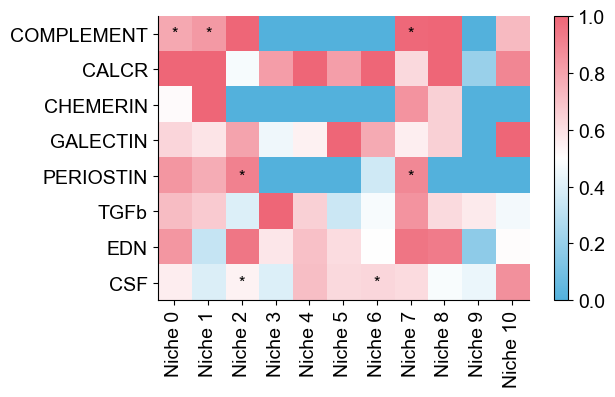

In [12]:
fdr_thresh = 0.05
fc_star_thresh = 0.5

def niche_num(x):
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else 10**9

# 1) Copy the table and compute BH-FDR within each pathway across niches
df = res_pw_top_niche.copy()

df["fdr_bh_pathway"] = 1.0
for pw, sub in df.groupby("pathway", sort=False):
    pvals = sub["p_mannwhitney"].astype(float).values
    df.loc[sub.index, "fdr_bh_pathway"] = multipletests(pvals, method="fdr_bh")[1]

df["niche_num"] = df["niche"].apply(niche_num)

# Sort niches for the x-axis
niche_order = sorted(df["niche"].unique().tolist(), key=niche_num)

# 2) Pivot the table: rows = pathways, columns = niches
mat = df.pivot_table(index="pathway", columns="niche",
                     values="log2FC_old_vs_young", aggfunc="mean")
pvt_fdr = df.pivot_table(index="pathway", columns="niche",
                         values="fdr_bh_pathway", aggfunc="min")

# 3) Keep only top_pathways in the provided order and sort niches numerically
mat = mat.reindex(index=top_pathways, columns=niche_order)
pvt_fdr = pvt_fdr.reindex(index=mat.index, columns=mat.columns)

# 4) Fix the color scale to 0-1
with plt.rc_context({'font.size': 14}):
    mat_plot = mat.fillna(0).clip(lower=0, upper=1)
    
    fig, ax = plt.subplots(figsize=(0.35*len(mat_plot.columns) + 2.5, 0.3*len(mat_plot.index) + 1.8))
    im = ax.imshow(mat_plot.values, aspect="auto", cmap=my_cmap, vmin=0, vmax=1)
    
    # x-axis: niches rotated by 90 degrees
    ax.set_xticks(np.arange(mat_plot.shape[1]))
    ax.set_xticklabels(mat_plot.columns.tolist(), rotation=90, ha="center")
    
    # y-axis: pathways
    ax.set_yticks(np.arange(mat_plot.shape[0]))
    ax.set_yticklabels(mat_plot.index.tolist())
    
    # 5) Add stars when FDR < 0.05 and logFC > 0.5 using the unclipped matrix
    for i in range(mat_plot.shape[0]):      # pathway rows
        for j in range(mat_plot.shape[1]):  # niche columns
            q = pvt_fdr.iat[i, j]
            fc = mat.iat[i, j]
            if pd.notna(q) and (q < fdr_thresh) and pd.notna(fc) and (fc > fc_star_thresh):
                ax.text(j, i, "*", ha="center", va="center",
                        color="black", fontsize=12, fontweight="bold")
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    cbar = plt.colorbar(im, ax=ax, fraction=0.06, pad=0.06)
    # cbar.set_label("log2FC (Old vs Young), clipped to [0,1]")
    
    plt.tight_layout()
    # plt.savefig("Pathway_Niche_heatmap.pdf", bbox_inches="tight")
    plt.show()

## Fig. 4c

In [13]:
def aggregate_lr_sig_counts_all_samples(
    all_data_dict,
    lr_dict,
    sample_list,
    pathway_list
):
    rows = []

    for sample in sample_list:
        adata = all_data_dict[sample]
        df = lr_dict[sample]

        for pw in pathway_list:
            lrs = df.loc[df["pathway"].astype(str) == str(pw), "complex"].tolist()

            for lr in lrs:
                sig_col = f"{lr}_sig"
                if sig_col not in adata.obs.columns:
                    continue

                v = adata.obs[sig_col]
                if v.dtype == object:
                    v = v.astype(str).str.lower().map({"true": True, "false": False})
                v = v.fillna(False).astype(bool)

                rows.append({
                    "pathway": pw,
                    "ligand_receptor": lr,
                    "sig_count": int(v.sum())
                })

    out = (
        pd.DataFrame(rows)
        .groupby(["pathway", "ligand_receptor"], as_index=False)
        .sum()
    )
    return out

In [14]:
color_list = ['#fdcf67', '#95c5b9', '#c996b6']

def plot_global_pathway_lr_sigcount(
    sig_df,
    topk_lr=10,
    color_list=None
):
    sig_df = sig_df.copy()

    sig_df["rank"] = (
        sig_df.groupby("pathway")["sig_count"]
        .rank(ascending=False, method="first")
    )

    top = sig_df[sig_df["rank"] <= topk_lr]
    other = (
        sig_df[sig_df["rank"] > topk_lr]
        .groupby("pathway", as_index=False)["sig_count"]
        .sum()
        .assign(ligand_receptor="Other")
    )

    plot_df = pd.concat(
        [top.drop(columns="rank"), other],
        ignore_index=True
    )

    P = plot_df.pivot_table(
        index="pathway",
        columns="ligand_receptor",
        values="sig_count",
        fill_value=0
    )

    # Sort LR pairs by total contribution
    P = P.loc[:, P.sum(axis=0).sort_values(ascending=False).index]

    n_cols = P.shape[1]
    if color_list is None:
        colors = None
    else:
        colors = [color_list[i % len(color_list)] for i in range(n_cols)]

    fig, ax = plt.subplots(figsize=(5, 4))
    P.plot(
        kind="bar",
        stacked=True,
        color=colors,
        ax=ax
    )

    ax.set_ylabel("Number of hotspots")
    ax.set_xlabel("")

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[::-1],
        labels[::-1],
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.tight_layout()
    return fig


In [15]:
pathway_list = ['COMPLEMENT', 'PERIOSTIN']
sig_all = aggregate_lr_sig_counts_all_samples(
    all_data_dict=all_data_dict,
    lr_dict=lr_dict,
    sample_list=sample_list,
    pathway_list=pathway_list
)

In [16]:
sig_all

,pathway,ligand_receptor,sig_count
0,COMPLEMENT,C3-C3ar1,548
1,COMPLEMENT,C3-Itgam_Itgb2,45
2,PERIOSTIN,Postn-Itgav_Itgb5,640


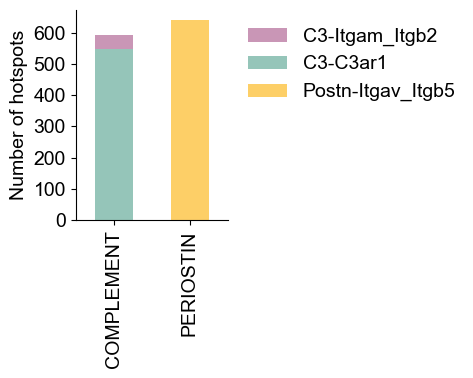

In [17]:
pathway_list = all_pathways

with plt.rc_context({'font.size': 14}):
    fig = plot_global_pathway_lr_sigcount(
        sig_all,
        topk_lr=8,
        color_list=color_list
    )
    fig.show()

## Fig. 4d

In [36]:
for adata in all_data_dict.values():
    adata.uns["Postn-Itgav_Itgb5_sig_colors"] = ["#DDDDDD", "#EE6677"]
    adata.uns["C3-C3ar1_sig_colors"] = ["#DDDDDD", "#EE6677"]

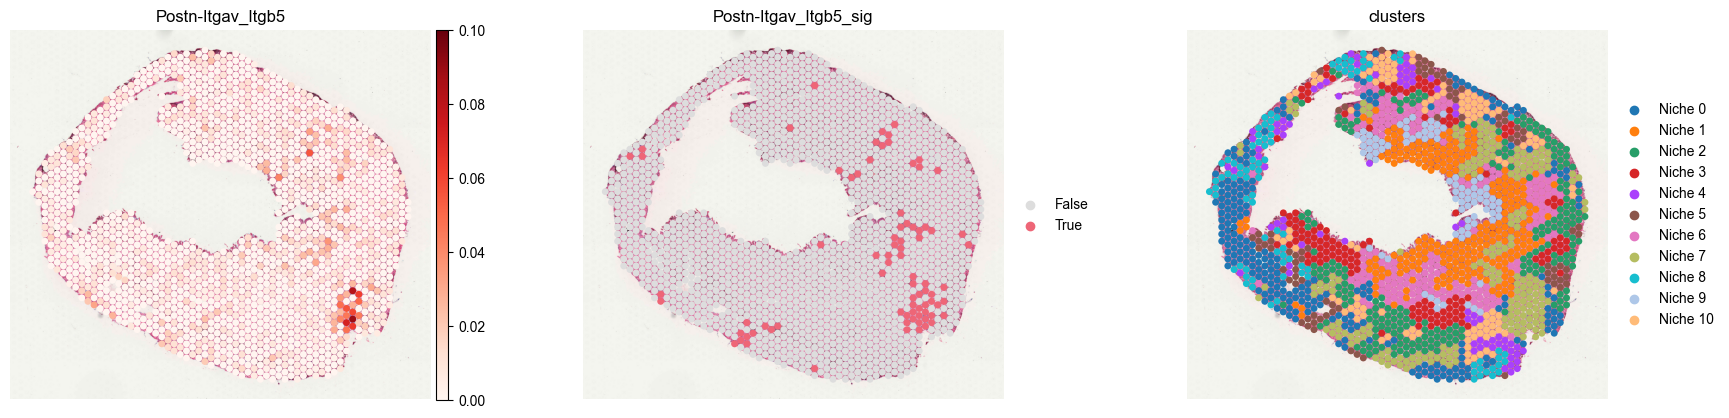

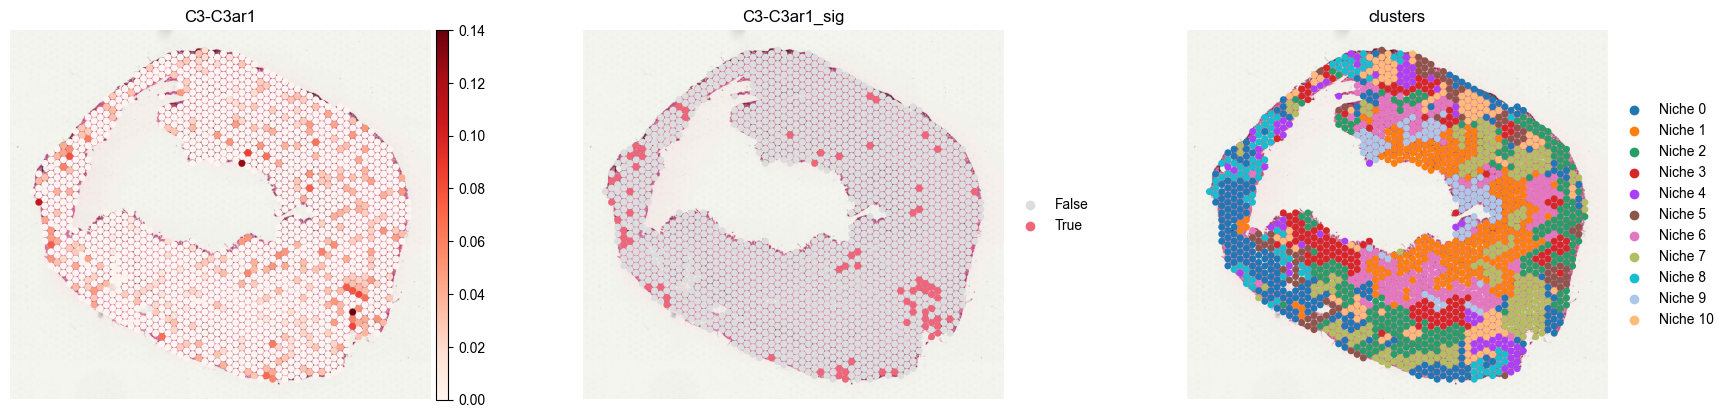

In [37]:
sc.pl.spatial(all_data_dict['Young_2'], color=['Postn-Itgav_Itgb5', 'Postn-Itgav_Itgb5_sig', 'clusters'], frameon=False,
         cmap="Reds", vmax=0.1, library_id='Young_2', size=1.5)
sc.pl.spatial(all_data_dict['Young_2'], color=['C3-C3ar1', 'C3-C3ar1_sig', 'clusters'], frameon=False,
         cmap="Reds", vmax=0.14, library_id='Young_2', size=1.5)

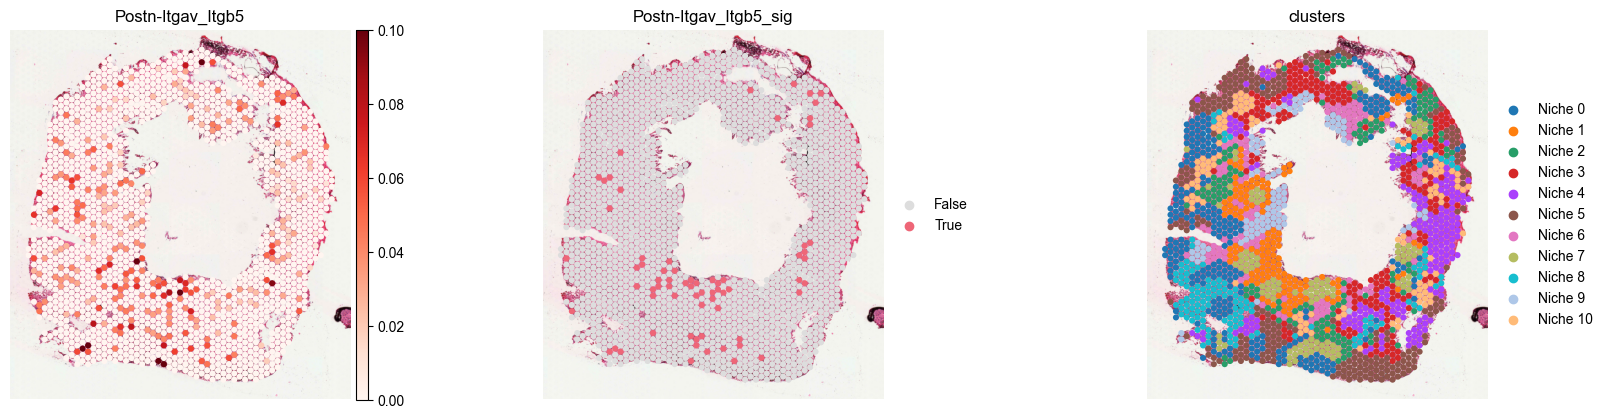

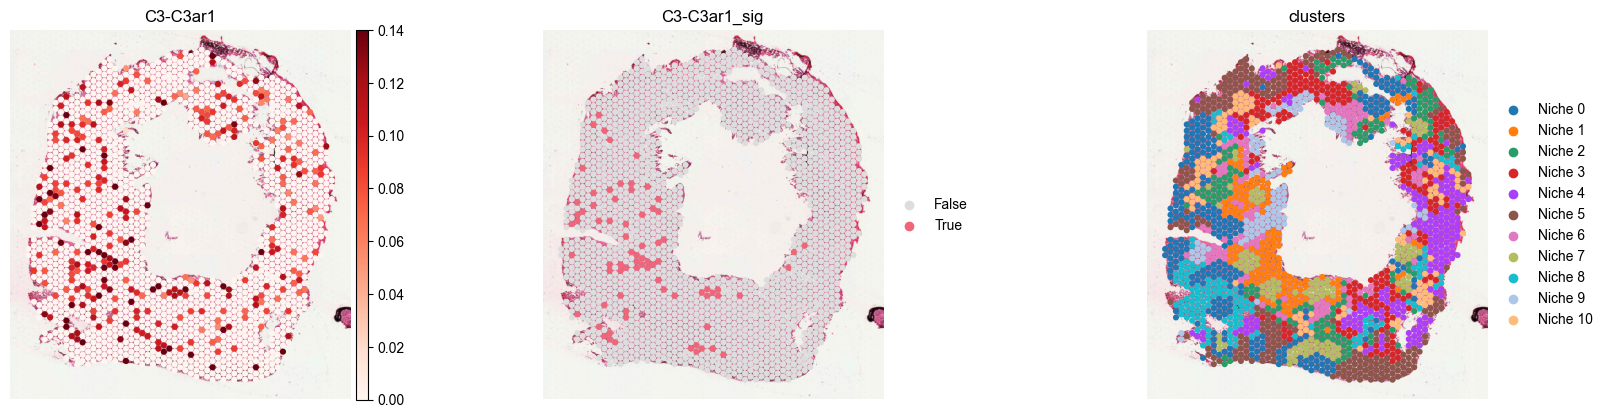

In [38]:
sc.pl.spatial(all_data_dict['Old_3'], color=['Postn-Itgav_Itgb5', 'Postn-Itgav_Itgb5_sig', 'clusters'], frameon=False,
         cmap="Reds", vmax=0.1, library_id='Old_3', size=1.5)
sc.pl.spatial(all_data_dict['Old_3'], color=['C3-C3ar1', 'C3-C3ar1_sig', 'clusters'], frameon=False,
         cmap="Reds", vmax=0.14, library_id='Old_3', size=1.5)

## Fig. 4f

In [20]:
per_adata_dict = {}
per_lr_dict = {}

for sample in sample_list:
    res_dir = Path(f"/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_perturbation_niche_7_results/{sample}")
    os.makedirs(res_dir, exist_ok=True)
    print(res_dir)
    adata = sc.read(res_dir / "downstream.h5ad")
    lr_df = pd.read_csv(res_dir / "filtered_secreted_LR_pairs.csv")
    per_lr_dict[sample] = lr_df
    per_adata_dict[sample] = adata

/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_perturbation_niche_7_results/Young_1
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_perturbation_niche_7_results/Young_2
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_perturbation_niche_7_results/Young_3
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_perturbation_niche_7_results/Young_4
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_perturbation_niche_7_results/Young_5
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_perturbation_niche_7_results/Old_1
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_perturbation_niche_7_results/Old_2
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_perturbation_niche_7_results/Old_3
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_perturbation_niche_7_results/Old_4
/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/spaflow_perturbation_niche_7_results/Old_5


In [21]:
def summarize_perturb_effect(
    adata_dict, per_adata_dict, lr_dict,
    niche_col="niche", source_niche="7",
    group_prefix="Old_"   # summarize only samples matching Old_*
):
    rows = []
    for sample in [s for s in adata_dict if s.startswith(group_prefix)]:
        A = adata_dict[sample]
        P = per_adata_dict[sample]
        lr_df = lr_dict[sample]

        # Align spots to avoid order or missing-value mismatches
        common = A.obs_names.intersection(P.obs_names)
        obsA = A.obs.loc[common]
        obsP = P.obs.loc[common]

        # Analyze only spots outside the source niche
        g = obsA[niche_col].astype(str)
        mask = g.ne(str(source_niche))

        # Iterate over LR pairs; the score column name is the complex name
        for lr in lr_df["complex"].astype(str).tolist():
            if lr not in obsA.columns or lr not in obsP.columns:
                continue

            x = pd.to_numeric(obsA.loc[mask, lr], errors="coerce")
            y = pd.to_numeric(obsP.loc[mask, lr], errors="coerce")
            d = (x - y).to_numpy()  # base - perturb

            tmp = pd.DataFrame({
                "niche": g.loc[mask].values,
                "delta": d
            }).dropna()

            if tmp.empty:
                continue

            s = tmp.groupby("niche")["delta"].agg(["mean", "median", "count"]).reset_index()
            s["sample"] = sample
            s["lr"] = lr
            rows.append(s)

    out = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    return out



In [22]:
# Run for the Old group only
effect_df_old = summarize_perturb_effect(
    adata_dict=adata_dict,
    per_adata_dict=per_adata_dict,
    lr_dict=lr_dict,
    niche_col="clusters",     # replace with your annotation column if needed
    source_niche="7",
    group_prefix = 'Old_'
)
effect_df_old = effect_df_old[effect_df_old['niche'] != 'Niche 7']

In [23]:
# Run for the Young group only
effect_df_young = summarize_perturb_effect(
    adata_dict=adata_dict,
    per_adata_dict=per_adata_dict,
    lr_dict=lr_dict,
    niche_col="clusters",     # replace with your annotation column if needed
    source_niche="7",
    group_prefix = 'Young_'
)
effect_df_young = effect_df_young[effect_df_young['niche'] != 'Niche 7']

In [24]:
def add_stats_old_vs_young_lr_fdr_within_niche(effect_df_old, effect_df_young):
    """
    effect_df_old / effect_df_young should already exclude niche 7.
    Run a Mann-Whitney U test for old vs young within each (lr, niche),
    then apply BH-FDR across LR pairs within each niche.

    Required columns: ['sample', 'lr', 'niche', 'mean'].
    Returns: stats_df with p-values and summary statistics.
    """
    df_old = effect_df_old.copy()
    df_yng = effect_df_young.copy()

    df_old["group"] = "old"
    df_yng["group"] = "young"
    df = pd.concat([df_old, df_yng], ignore_index=True)

    out = []
    for (lr, niche), sub in df.groupby(["lr", "niche"], sort=False):
        x = pd.to_numeric(sub.loc[sub["group"] == "old", "mean"], errors="coerce").dropna().values
        y = pd.to_numeric(sub.loc[sub["group"] == "young", "mean"], errors="coerce").dropna().values

        p = np.nan
        if len(x) >= 3 and len(y) >= 3:
            p = mannwhitneyu(x, y, alternative="two-sided").pvalue

        out.append({
            "lr": lr,
            "niche": niche,
            "mean_old": np.nanmean(x) if len(x) else np.nan,
            "mean_young": np.nanmean(y) if len(y) else np.nan,
            "delta_old_young": (np.nanmean(x) - np.nanmean(y)) if (len(x) and len(y)) else np.nan,
            "p": p,
            "n_old": len(x),
            "n_young": len(y),
        })

    stats_df = pd.DataFrame(out)


    return stats_df

In [25]:
def make_heat_and_stars(stats_df, top_k=15, q_cut=0.05):
    """
    stats_df must contain at least ['lr', 'niche', 'delta_old_young', 'p'].
    Workflow:
      1) Select the top_k LR candidates by effect size.
      2) Apply BH-FDR within each LR across its niches.
      3) Build a heatmap from delta_old_young and overlay stars where q < q_cut.
    """
    # 1) Select top LR pairs
    top_lrs = (stats_df.groupby("lr")["delta_old_young"]
               .mean()
               .sort_values(ascending=False)
               .head(top_k)
               .index)

    sub = stats_df[stats_df["lr"].isin(top_lrs)].copy()

    # 2) Apply BH-FDR within each LR across niches
    sub["q"] = np.nan
    for lr, idx in sub.groupby("lr").groups.items():
        pvals = pd.to_numeric(sub.loc[idx, "p"], errors="coerce").values
        mask = ~np.isnan(pvals)
        if mask.sum() == 0:
            continue
        qvals = np.full_like(pvals, np.nan, dtype=float)
        qvals[mask] = multipletests(pvals[mask], method="fdr_bh")[1]
        sub.loc[idx, "q"] = qvals

    # 3) Pivot into heat / q / star matrices
    heat_df = sub.pivot_table(index="niche", columns="lr",
                              values="delta_old_young", aggfunc="mean")
    q_df = sub.pivot_table(index="niche", columns="lr",
                           values="q", aggfunc="mean")

    # Align matrices to avoid shape mismatches
    q_df = q_df.reindex(index=heat_df.index, columns=heat_df.columns)

    # Star matrix
    star_df = q_df.map(lambda v: "" if pd.isna(v) else ("*" if v < q_cut else ""))

    return sub, heat_df, star_df, q_df

In [26]:
def plot_heatmap_with_stars(heat_df, star_df, figure_size=(7, 5), star_size=16):
    # --- sort rows by Niche 1..10 (and keep others after) ---
    def niche_num(x):
        m = re.search(r"(\d+)", str(x))
        return int(m.group(1)) if m else 10**9

    row_order = sorted(heat_df.index, key=niche_num)
    heat_df = heat_df.loc[row_order]
    star_df = star_df.reindex(index=heat_df.index, columns=heat_df.columns)

    fig, ax = plt.subplots(figsize=figure_size)
    sns.heatmap(
        heat_df.T,
        cmap="RdBu_r",
        center=0,
        linewidths=0.5,
        annot=star_df.T,
        fmt="",
        annot_kws={"fontsize": star_size, "fontweight": "bold"},
        cbar_kws={"label": "Reduction (Old − Young)"},
        ax=ax
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    fig.tight_layout()
    return fig


In [27]:
stats_df = add_stats_old_vs_young_lr_fdr_within_niche(effect_df_old, effect_df_young)
stats_df

,lr,niche,mean_old,mean_young,delta_old_young,p,n_old,n_young
0,Tgfb1-Tgfbr1_Tgfbr2,Niche 0,0.000129,0.000143,-1.461932e-05,0.690476,5,5
1,Tgfb1-Tgfbr1_Tgfbr2,Niche 1,0.000177,0.000219,-4.207883e-05,0.420635,5,5
2,Tgfb1-Tgfbr1_Tgfbr2,Niche 10,0.000043,0.000042,1.799427e-06,0.841270,5,5
3,Tgfb1-Tgfbr1_Tgfbr2,Niche 2,0.000122,0.000125,-3.141288e-06,0.841270,5,5
4,Tgfb1-Tgfbr1_Tgfbr2,Niche 3,0.000018,0.000018,-6.594193e-08,1.000000,5,5
...,...,...,...,...,...,...,...,...
2025,Retn-Cap1,Niche 4,NaN,0.000049,NaN,NaN,0,1
2026,Retn-Cap1,Niche 5,NaN,0.000002,NaN,NaN,0,1
2027,Retn-Cap1,Niche 6,NaN,0.000122,NaN,NaN,0,1
2028,Retn-Cap1,Niche 8,NaN,0.000186,NaN,NaN,0,1


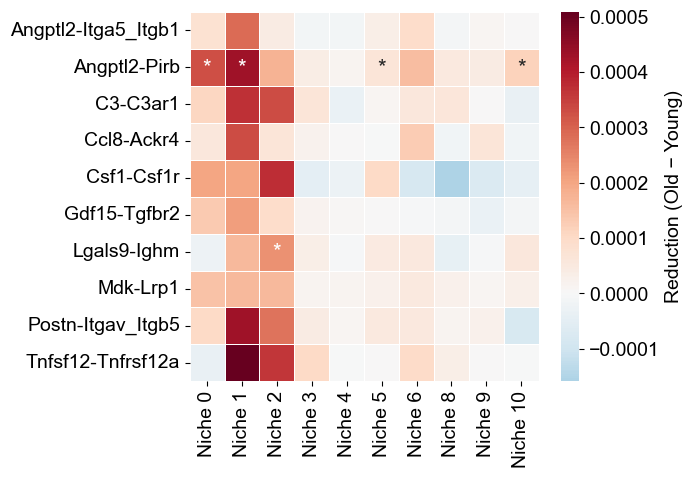

In [28]:
sub, heat_df, star_df, q_df = make_heat_and_stars(stats_df, top_k=10, q_cut=0.1)
with plt.rc_context({'font.size': 14}):
    fig = plot_heatmap_with_stars(heat_df, star_df)
    # fig.savefig("Perturbation_Niche7_reducion.pdf", bbox_inches='tight')
    plt.show()

## Fig. 4g

In [29]:
data_path = "/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/snRNA_RefAging_Manuscript.h5ad"

sc_adata = sc.read(data_path)
sc_adata

AnnData object with n_obs × n_vars = 64845 × 25425
    obs: 'sample', 'condition', 'Experiment', 'leiden1_5', 'autoAnnot', 'annotation', 'leiden5', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'batch', 'age'
    var: 'GeneSymbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'age_colors', 'annotation_colors', 'autoAnnot_colors', 'batch_colors', 'condition_colors', 'hvg', 'leiden1_5', 'leiden1_5_colors', 'leiden5', 'leiden5_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

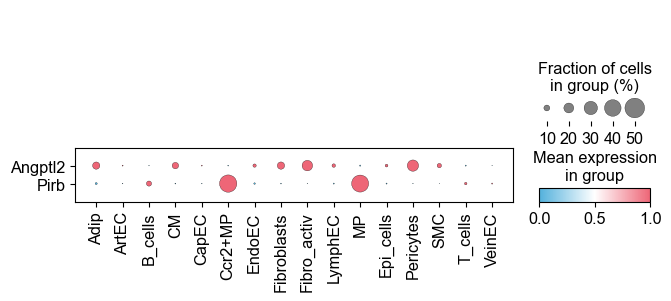

In [30]:
# Using logcounts
with plt.rc_context({'font.size': 14}):
    sc.pl.dotplot(sc_adata, var_names = ['Angptl2', 'Pirb'], layer='logcounts', groupby='annotation',
                 cmap=my_cmap, standard_scale='var', show=False, swap_axes=True)
    plt.show()

## Fig.4h

In [31]:
sp_all_adata = sc.read("/fs/ess/PAS1475/huchen/Diffusion/Mouse_Heart_Visium/datasets/Visium_YoungOld_AgingProject_28August_Cleaned.h5ad")
sp_all_adata

AnnData object with n_obs × n_vars = 15838 × 19670
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'sample', 'lab', 'condition', 'replicate', 'timepoint', 'AnatomicRegion', 'leiden_STAligner', 'clusters', 'Adip', 'ArtEC', 'B_cells', 'CM', 'CapEC', 'EndoEC', 'Fibroblasts', 'Fibro_activ', 'LymphEC', 'MP', 'Epi_cells', 'Ccr2+MP', 'Pericytes', 'SMC', 'T_cells', 'VeinEC', 'nCells', 'vessels', 'FB_Hexa', 'FBa_Hexa', 'EndoEpi_Hexa', 'Hexa_cutoff', 'log1p_total_counts', 'senescence', 'senescence_gradient'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'Hb', 'mt', 'SCT_rm'
    uns: 'AnatomicRegion_colors', 'FB_Hexa_colors', 'FBa_Hexa_colors', 'condition_colors', 'hvg', 'leiden_STAligner_colors', 'leiden_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'sample_

In [32]:
cell_types = ['Adip','ArtEC','B_cells','CM','CapEC','EndoEC','Fibroblasts','Fibro_activ',
              'LymphEC','MP','Epi_cells','Ccr2+MP','Pericytes','SMC','T_cells','VeinEC']

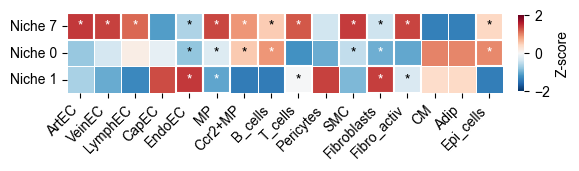

In [33]:
# ----------------------------
# settings
# ----------------------------
cluster_col = "clusters"

cell_types = [
    "ArtEC", "VeinEC", "LymphEC", "CapEC", "EndoEC", "MP", "Ccr2+MP",
    "B_cells", "T_cells", "Pericytes", "SMC", "Fibroblasts",
    "Fibro_activ", "CM", "Adip", "Epi_cells"
]

niche_order = ["Niche 7", "Niche 0", "Niche 1"]

# ----------------------------
# 1) mean cell type proportion within each niche
# ----------------------------
df = sp_all_adata.obs[[cluster_col] + cell_types].copy()
df[cluster_col] = df[cluster_col].astype(str)

mean_prop = df.groupby(cluster_col)[cell_types].mean()
niche_order = [x for x in niche_order if x in mean_prop.index]
mean_prop = mean_prop.loc[niche_order, cell_types]

# ----------------------------
# 2) Z-score transform across niches for each cell type
# ----------------------------
zscore_mat = mean_prop.copy()
for ct in cell_types:
    vals = mean_prop[ct].astype(float)
    sd = vals.std(ddof=0)
    if sd == 0:
        zscore_mat[ct] = 0.0
    else:
        zscore_mat[ct] = (vals - vals.mean()) / sd

# Display horizontally: rows = niches, columns = cell types
plot_mat = zscore_mat.loc[niche_order, cell_types]

# ----------------------------
# 3) significance test
#    each niche vs all other niches
# ----------------------------
eps = 1e-9
tests = []
pvals = []

for niche in niche_order:
    in_niche = df[cluster_col] == niche
    out_niche = df[cluster_col] != niche

    for ct in cell_types:
        x = df.loc[in_niche, ct].astype(float).values
        y = df.loc[out_niche, ct].astype(float).values

        _, p = mannwhitneyu(x, y, alternative="two-sided")
        log2fc = np.log2((x.mean() + eps) / (y.mean() + eps))

        tests.append((niche, ct, log2fc))
        pvals.append(p)

padj = multipletests(pvals, method="fdr_bh")[1]

sig_df = pd.DataFrame(tests, columns=["niche", "cell_type", "log2fc"])
sig_df["padj"] = padj
sig_df["significant"] = (sig_df["padj"] < 0.05) & (sig_df["log2fc"] > 0.25)

sig_mat = (
    sig_df.pivot(index="niche", columns="cell_type", values="significant")
    .reindex(index=niche_order, columns=cell_types)
    .fillna(False)
)

# ----------------------------
# 4) plot
# ----------------------------
fig, ax = plt.subplots(figsize=(6, 1.8))

sns.heatmap(
    plot_mat,
    cmap="RdBu_r",
    center=0,
    vmin=-2,
    vmax=2,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Z-score",
        "fraction": 0.12,   # increase the colorbar width
        "pad": 0.03,        # spacing between the heatmap and colorbar
        "shrink": 0.95,     # control the colorbar length
        "aspect": 12        # smaller values make the bar thicker
    },
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# add significance boxes + star
for i, niche in enumerate(niche_order):
    for j, ct in enumerate(cell_types):
        if sig_mat.loc[niche, ct]:
            val = plot_mat.loc[niche, ct]
            star_color = "black" if abs(val) < 0.8 else "white"

            ax.add_patch(Rectangle((j, i), 1, 1, fill=False, edgecolor="white", linewidth=1.5))
            ax.text(
                j + 0.5, i + 0.5, "*",
                ha="center", va="center",
                color=star_color, fontsize=10, fontweight="bold"
            )

plt.tight_layout()
# plt.savefig("Ct_proportion_heatmap.pdf", bbox_inches="tight")
plt.show()
